In [1]:
import copy
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

In [2]:
def dataframe_to_sklearn_dataset(df):
    """
    Convert a pandas DataFrame into an sklearn-style regression dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with 82 columns:
        - first 81 columns are features
        - last column is the target

    Returns
    -------
    dict
        sklearn-style dataset dictionary
    """

    feature_names = df.columns[:-1].tolist()
    target_name = df.columns[-1]

    data = df.iloc[:, :-1].to_numpy(dtype=float)
    target = df.iloc[:, -1].to_numpy(dtype=float)

    dataset = {
        "data": data,
        "target": target,
        "frame": None,
        "target_names": [target_name],
        "feature_names": feature_names,
    }

    return dataset

In [13]:
data_cali = fetch_california_housing()
print(data_cali)
print(data_cali.DESCR)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

In [3]:
data = pd.read_csv(r'C:\Users\amyry\OneDrive - University of Cambridge\NanoDTC_\Coding\pml_supercond\data\raw\train.csv')

data_sk = dataframe_to_sklearn_dataset(data)
print(data_sk)

{'data': array([[ 4.        , 88.9444675 , 57.86269229, ...,  1.08571429,
         0.4330127 ,  0.43705882],
       [ 5.        , 92.729214  , 58.51841614, ...,  1.12857143,
         0.63245553,  0.46860627],
       [ 4.        , 88.9444675 , 57.88524186, ...,  1.11428571,
         0.4330127 ,  0.44469664],
       ...,
       [ 2.        , 99.66319   , 95.609104  , ...,  3.2       ,
         0.5       ,  0.4       ],
       [ 2.        , 99.66319   , 97.0956022 , ...,  2.21      ,
         0.5       ,  0.46249324],
       [ 3.        , 87.46833333, 86.8585    , ...,  1.8       ,
         1.41421356,  1.5       ]], shape=(21263, 81)), 'target': array([29.  , 26.  , 19.  , ...,  1.98,  1.84, 12.8 ], shape=(21263,)), 'frame': None, 'target_names': ['critical_temp'], 'feature_names': ['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 

In [4]:
# Read data
X, y = data_sk['data'], data_sk['target']
 
# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
 
# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


In [20]:
# Define the model
model = nn.Sequential(
    nn.Linear(81, 27),
    nn.ReLU(),
    nn.Linear(27, 9),
    nn.ReLU(),
    nn.Linear(9, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)
 


Epoch 0: MSE = 583.36
Epoch 1: MSE = 489.06
Epoch 2: MSE = 443.87
Epoch 3: MSE = 421.44
Epoch 4: MSE = 398.67
Epoch 5: MSE = 374.30
Epoch 6: MSE = 357.75
Epoch 7: MSE = 343.23
Epoch 8: MSE = 332.99
Epoch 9: MSE = 329.53
Epoch 10: MSE = 322.19
Epoch 11: MSE = 314.26
Epoch 12: MSE = 309.45
Epoch 13: MSE = 303.70
Epoch 14: MSE = 300.72
Epoch 15: MSE = 298.74
Epoch 16: MSE = 294.96
Epoch 17: MSE = 292.38
Epoch 18: MSE = 290.20
Epoch 19: MSE = 288.00
Epoch 20: MSE = 285.80
Epoch 21: MSE = 283.44
Epoch 22: MSE = 282.11
Epoch 23: MSE = 280.57
Epoch 24: MSE = 279.19
Epoch 25: MSE = 278.20
Epoch 26: MSE = 276.63
Epoch 27: MSE = 274.38
Epoch 28: MSE = 273.40
Epoch 29: MSE = 272.58
Epoch 30: MSE = 271.83
Epoch 31: MSE = 269.40
Epoch 32: MSE = 267.60
Epoch 33: MSE = 267.18
Epoch 34: MSE = 266.63
Epoch 35: MSE = 265.98
Epoch 36: MSE = 263.58
Epoch 37: MSE = 262.98
Epoch 38: MSE = 265.11
Epoch 39: MSE = 260.96
Epoch 40: MSE = 261.08
Epoch 41: MSE = 262.21
Epoch 42: MSE = 262.58
Epoch 43: MSE = 260.2

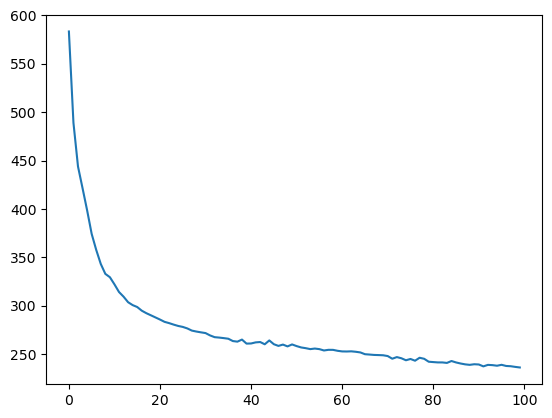

In [21]:
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)
 
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: MSE = {mse:.2f}")
 
# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()

MSE: 236.30

RMSE: 15.37

after 100 epochs


# things this doesn't do

- reduce number of parameters inputted instead of throwing all 81 at it
- any sort of normalisation of inputted data?
- show examples of test predictions vs actual (more visualisation of results than just the loss function)

# with norm


In [5]:
X_norm = X / X.max(axis=0)
y_max = y.max()
y_norm = y / y_max
print(y_max)

# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
 
# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

185.0


In [6]:
# Define the model
model = nn.Sequential(
    nn.Linear(81, 27),
    nn.ReLU(),
    nn.Linear(27, 9),
    nn.ReLU(),
    nn.Linear(9, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)
 


C:\Users\amyry\AppData\Local\Temp\ipykernel_36564\1295152282.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  bar.set_postfix(mse=float(loss))


Epoch 0: MSE = 624.58
Epoch 1: MSE = 508.36
Epoch 2: MSE = 459.85
Epoch 3: MSE = 438.27
Epoch 4: MSE = 418.80
Epoch 5: MSE = 398.89
Epoch 6: MSE = 383.55
Epoch 7: MSE = 368.57
Epoch 8: MSE = 356.54
Epoch 9: MSE = 348.19
Epoch 10: MSE = 340.97
Epoch 11: MSE = 333.69
Epoch 12: MSE = 326.53
Epoch 13: MSE = 321.08
Epoch 14: MSE = 318.02
Epoch 15: MSE = 312.96
Epoch 16: MSE = 309.57
Epoch 17: MSE = 307.37
Epoch 18: MSE = 304.59
Epoch 19: MSE = 303.29
Epoch 20: MSE = 300.88
Epoch 21: MSE = 298.73
Epoch 22: MSE = 297.97
Epoch 23: MSE = 296.60
Epoch 24: MSE = 293.70
Epoch 25: MSE = 292.73
Epoch 26: MSE = 291.75
Epoch 27: MSE = 291.30
Epoch 28: MSE = 289.30
Epoch 29: MSE = 287.80
Epoch 30: MSE = 286.82
Epoch 31: MSE = 287.05
Epoch 32: MSE = 286.42
Epoch 33: MSE = 285.26
Epoch 34: MSE = 284.50
Epoch 35: MSE = 283.58
Epoch 36: MSE = 282.76
Epoch 37: MSE = 282.50
Epoch 38: MSE = 282.07
Epoch 39: MSE = 281.43
Epoch 40: MSE = 281.08
Epoch 41: MSE = 280.19
Epoch 42: MSE = 280.88
Epoch 43: MSE = 280.9

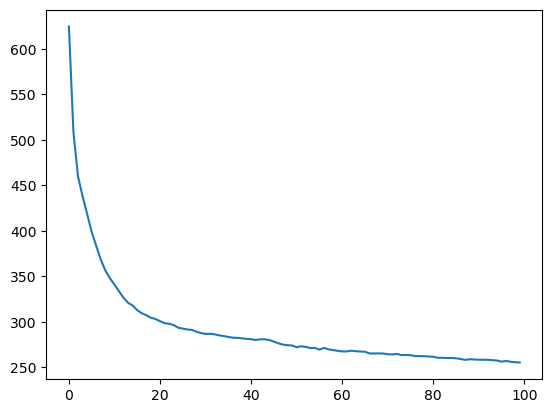

In [7]:
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)
 
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []
 
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: MSE = {mse:.2f}")
 
# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()